In [846]:
import numpy as np
import matplotlib.pyplot as plt


In [847]:
def plot_data(X, y):
    plt.figure(figsize=[5,5]) ## equal x and y lengths for a squared figure
    plt.scatter(X[:, 0], X[:, 1], c=y, s = 100, alpha = 0.7)
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')

Dans ce TP nous allons implémenter un réseau de neurones à une couche.

Nos premières données sont le XOR que vous connaissez maintenant bien.

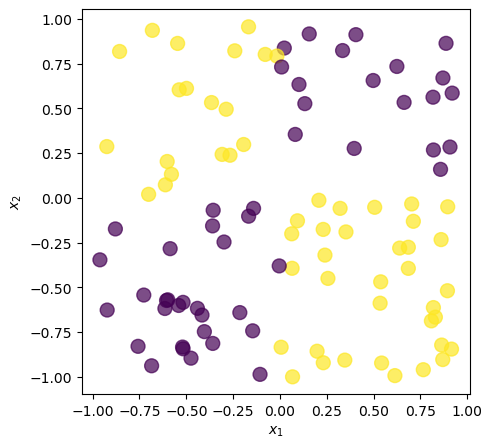

In [848]:
n_points = 100 
X = np.random.uniform(-1, 1, size=(n_points, 2))

y = np.where( X[:, 0] * X[:, 1] < 0 , 1,-1)

plot_data(X,y)

**Question 1**

Implémentez la fonction ReLU ainsi que sa dérivée, pour rappel :

$ReLU(x) = \max(0,x)$


In [849]:
def ReLU(x):
    ''' Retourne ReLU(x) '''
    return np.where(x>0,x,0)

def ReLU_prime(x):
    ''' Retourne ReLU'(x) '''
    return np.where(x>0,1,0)

**Question 2**

Implémentez la fonction de prédiction d'un réseau à une couche. 

Rappel, la sortie est :

$ h(\vec{x}) = \vec{w}.\phi(\vec{x}) + b$

avec 

$  \phi(\vec{x}) = \sigma(U\vec{x})$


In [850]:
def pred_MLE(X,w,U,b):
    '''
    Input :
    X : les (ou la) données
    w, U, b : les paramètres du réseau de neurone
    sigma : la fonction d'activation
    Output :
    h(x) : la sortie du réseau de neurone
    '''
    return ReLU(X@U)@w + b

In [851]:
# On vous donne la fonction qui calcule le score (c'est la même que pour perceptron)
def score_MLE(X,y,w,U,b):
    return np.sum((y*pred_MLE(X,w,U,b) > 0))/X.shape[0]

**Question 3**

Implémenter l'apprentissage du réseau de neurone à une couche, la fonction est guidée.

La formule de prédiction sont :

$$ h(\vec{x}) = \vec{w}.\phi(\vec{x}) + b $$

avec,

$$ \phi(\vec{x}) = \sigma(U\vec{x})$$

Une donnée $\vec{x}_i$ est bien prédite si $h(\vec{x}_i)$ est du même signe que $y_i$, la loss est :

$$ \mathcal{L}(\Theta,X,Y) =  \frac{1}{N}\sum_{n=1}^N \log(1+e^{-y_nh(\vec{x}_n)}) $$

In [852]:

def fit_MLE(X, y, H, eta=0.01, max_Iter=10_000):
    D = X.shape[1]
    N = X.shape[0]
    w = np.random.randn(H) 
    U = np.random.randn(D, H)
    b = 0.0
    iter = 0
    score = 0
    lscore = []


    while  iter < max_Iter:

        iter += 1
        # Calcul de la loss
        phi = ReLU(X@U)
        h = phi@w + b
        loss = 1/N*np.sum(1+np.exp(-y * h ))
        # Descente de gradient
        dh = -y / (1+ np.exp(y*h)) 
        db = np.sum(dh)
        dw = dh@phi
        dU = w*((np.transpose(X)*dh)@ReLU_prime(X@U))

        w -= 1/N * eta * dw
        U -= 1/N * eta * dU
        b -= 1/N * eta * db

        score  = score_MLE(X,y,w,U,b)
        lscore.append(score)

    return w, U, b, lscore

**Question 4**

Découpez vos données en train / test, calculez le score sur chacun

In [853]:
H = 8
N = X.shape[0]
N_train = N*4//5
X_train = X[:N_train]
y_train = y[:N_train]
X_test = X[N_train:]
y_test = y[N_train:]

w,U,b,_ = fit_MLE(X_train,y_train,H,max_Iter=10_000)

print(score_MLE(X_train,y_train,w,U,b))

print(score_MLE(X_test,y_test,w,U,b))



0.9875
1.0


    **Question 5** 

Affichez le learning rate, c'est à dire le training score (ou la loss, ou les deux) en fonction du nombre d'itérations. 

Pour cela modifiez `fit_MLE` pour sauvegarder dans une liste le score à chaque itération.

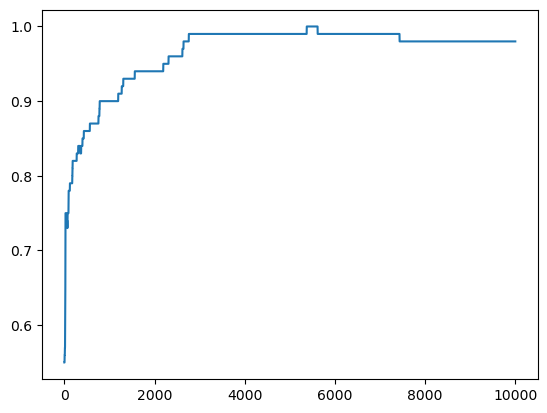

In [854]:
# Modifiez fit_MLE pour renvoyer égallement la liste des scores, rien à modifier dans le code ci dessous 
w,U,b,lscore = fit_MLE(X,y,H)
plt.plot(range(1,len(lscore)+1),lscore)

**Question 6**

Affichez le score en fonction de H, sur train et sur test.

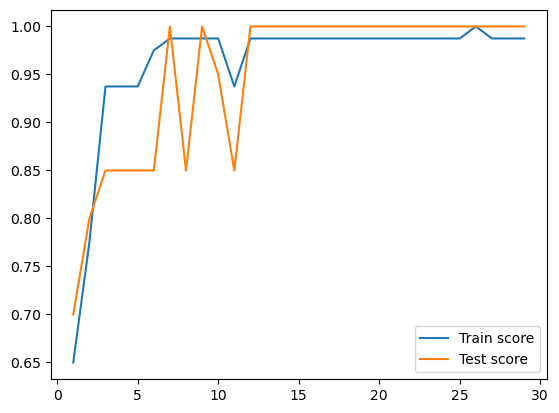

In [855]:


train_score = []
test_score = []
for h in range(1,30):
    w,U,b,_ = fit_MLE(X_train,y_train,h, max_Iter=30_000)
    train_score.append(score_MLE(X_train,y_train,w,U,b))
    test_score.append(score_MLE(X_test,y_test,w,U,b))

plt.plot(range(1,30),train_score,label='Train score')
plt.plot(range(1,30),test_score,label='Test score')
plt.legend()

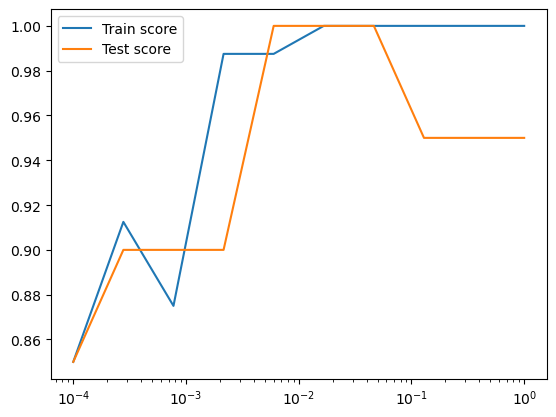

In [ ]:

train_score = []
test_score = []
H=8
etas = np.logspace(-4, 0, 10)
for eta in etas:
    w,U,b,_ = fit_MLE(X_train,y_train,H,eta=eta, max_Iter=30_000)
    train_score.append(score_MLE(X_train,y_train,w,U,b))
    test_score.append(score_MLE(X_test,y_test,w,U,b))

plt.semilogx(etas,train_score,label='Train score')
plt.semilogx(etas,test_score,label='Test score')
plt.legend()

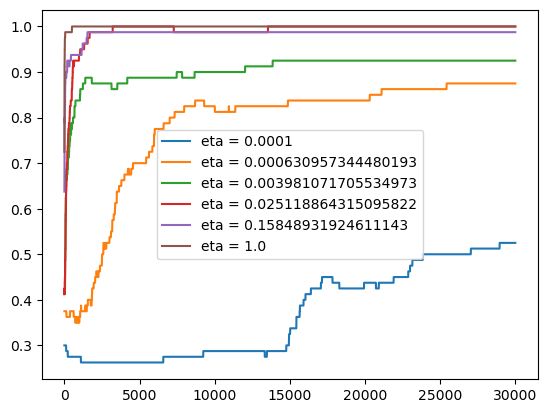

In [863]:

lscore = []
H=8
etas = np.logspace(-4, 0, 6)
for eta in etas:
    w,U,b,score = fit_MLE(X_train,y_train,H,eta=eta, max_Iter=30_000)
    lscore.append(score)

for i,eta in enumerate(etas):
    plt.plot(range(1,30_000+1),lscore[i],label = f'eta = {eta}')
plt.legend()

In [857]:
# np.random.seed(42)
# n_points = 200
# X = np.random.uniform(-2, 2, size=(n_points, 2))
# y = np.sign(np.sin(X[:, 0] * np.pi) * np.sin(X[:, 1] * np.pi))
# y[y == 0] = 1

# plot_data(X,y)


In [858]:
# N_train = N*3//5
# X_train = X[:N_train]
# y_train = y[:N_train]
# X_test = X[N_train:]
# y_test = y[N_train:]


# train_score = []
# test_score = []
# for h in range(1,100,3):
#     w,U,b,_ = fit_MLE(X_train,y_train,h, max_Iter=40_000)
#     train_score.append(score_MLE(X_train,y_train,w,U,b))
#     test_score.append(score_MLE(X_test,y_test,w,U,b))

# plt.plot(range(1,100,3),train_score,label='Train score')
# plt.plot(range(1,100,3),test_score,label='Test score')
# plt.legend()